#### Employee Performance Prediction System Using Machine Learning

#Objective :
Develop baseline machine learning models to predict whether an employee meets more than 80% of KPIs. Evaluate multiple scaling techniques and compare model performance using accuracy and confusion matrices.

#### Dataset Description

- HR Employee Dataset
- Binary Classification Problem
- Target Variable: KPIs_met >80%
- Objective: Predict whether an employee is likely to achieve more than 80% KPI performance.

In [7]:
# STEP 1 : IMPORT REQUIRED LIBRARIES
import pandas as pd
import numpy as np


In [8]:
# STEP 2 : READ DATASET
df = pd.read_csv("Test_data.csv")

In [9]:
# Step 3
# Display first 5 rows

df.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score
0,8724,Technology,region_26,Bachelor's,m,sourcing,1,24,NaN,1,1,0,77
1,74430,HR,region_4,Bachelor's,f,other,1,31,3.0,5,0,0,51
2,72255,Sales & Marketing,region_13,Bachelor's,m,other,1,31,1.0,4,0,0,47
3,38562,Procurement,region_2,Bachelor's,f,other,3,31,2.0,9,0,0,65
4,64486,Finance,region_29,Bachelor's,m,sourcing,1,30,4.0,7,0,0,61


In [10]:
# Step 4 :Display Last 5 Rows
df.tail()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score
23485,53478,Legal,region_2,Below Secondary,m,sourcing,1,24,3.0,1,0,0,61
23486,25600,Technology,region_25,Bachelor's,m,sourcing,1,31,3.0,7,0,0,74
23487,45409,HR,region_16,Bachelor's,f,sourcing,1,26,4.0,4,0,0,50
23488,1186,Procurement,region_31,Bachelor's,m,sourcing,3,27,NaN,1,0,0,70
23489,5973,Technology,region_17,Master's & above,m,other,3,40,5.0,5,1,0,89


In [11]:
#Step 5: Check Shape of Dataset
print("Rows and Columns :", df.shape)

Rows and Columns : (23490, 13)


In [12]:
#Step 6: Column Names
print(df.columns)

Index(['employee_id', 'department', 'region', 'education', 'gender',
       'recruitment_channel', 'no_of_trainings', 'age', 'previous_year_rating',
       'length_of_service', 'KPIs_met >80%', 'awards_won?',
       'avg_training_score'],
      dtype='object')


In [13]:
#Step 7: Data Types
df.dtypes

employee_id               int64
department               object
region                   object
education                object
gender                   object
recruitment_channel      object
no_of_trainings           int64
age                       int64
previous_year_rating    float64
length_of_service         int64
KPIs_met >80%             int64
awards_won?               int64
avg_training_score        int64
dtype: object

In [14]:
#Step 8: Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23490 entries, 0 to 23489
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           23490 non-null  int64  
 1   department            23490 non-null  object 
 2   region                23490 non-null  object 
 3   education             22456 non-null  object 
 4   gender                23490 non-null  object 
 5   recruitment_channel   23490 non-null  object 
 6   no_of_trainings       23490 non-null  int64  
 7   age                   23490 non-null  int64  
 8   previous_year_rating  21678 non-null  float64
 9   length_of_service     23490 non-null  int64  
 10  KPIs_met >80%         23490 non-null  int64  
 11  awards_won?           23490 non-null  int64  
 12  avg_training_score    23490 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 2.3+ MB


In [15]:
#Step 9: Statistical Summary
df.describe()

,employee_id,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score
count,23490.000000,23490.000000,23490.000000,21678.000000,23490.000000,23490.000000,23490.000000,23490.000000
mean,39041.399149,1.254236,34.782929,3.339146,5.810387,0.358834,0.022776,63.263133
std,22640.809201,0.600910,7.679492,1.263294,4.207917,0.479668,0.149191,13.411750
min,3.000000,1.000000,20.000000,1.000000,1.000000,0.000000,0.000000,39.000000
25%,19370.250000,1.000000,29.000000,3.000000,3.000000,0.000000,0.000000,51.000000
50%,38963.500000,1.000000,33.000000,3.000000,5.000000,0.000000,0.000000,60.000000
75%,58690.000000,1.000000,39.000000,4.000000,7.000000,1.000000,0.000000,76.000000
max,78295.000000,9.000000,60.000000,5.000000,34.000000,1.000000,1.000000,99.000000


In [16]:
#Step 10: Check Missing Values
df.isnull().sum()

employee_id                0
department                 0
region                     0
education               1034
gender                     0
recruitment_channel        0
no_of_trainings            0
age                        0
previous_year_rating    1812
length_of_service          0
KPIs_met >80%              0
awards_won?                0
avg_training_score         0
dtype: int64

In [17]:
#Step 11: Check Duplicate Rows
df.duplicated().sum()

np.int64(0)

In [18]:
#Step 12: Count Unique Values
df.nunique()

employee_id             23490
department                  9
region                     34
education                   3
gender                      2
recruitment_channel         3
no_of_trainings             9
age                        41
previous_year_rating        5
length_of_service          34
KPIs_met >80%               2
awards_won?                 2
avg_training_score         61
dtype: int64

## Data Preprocessing

In [19]:
# CHECK MISSING VALUES
df.isnull().sum()

employee_id                0
department                 0
region                     0
education               1034
gender                     0
recruitment_channel        0
no_of_trainings            0
age                        0
previous_year_rating    1812
length_of_service          0
KPIs_met >80%              0
awards_won?                0
avg_training_score         0
dtype: int64

#### Fill Missing Values-For Categorical Columns


In [20]:
#finding records of education column having null values
df.loc[df.education.isnull()]

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score
49,3720,Sales & Marketing,region_2,NaN,m,sourcing,1,36,5.0,4,1,0,49
67,26977,Operations,region_2,NaN,m,sourcing,1,28,3.0,3,0,0,59
89,2347,Analytics,region_15,NaN,m,other,2,37,5.0,8,1,0,82
127,42719,Analytics,region_21,NaN,m,sourcing,1,27,NaN,1,0,0,80
138,2721,Analytics,region_22,NaN,f,sourcing,2,26,5.0,3,1,0,86
...,...,...,...,...,...,...,...,...,...,...,...,...,...
23415,14036,Sales & Marketing,region_7,NaN,m,other,6,26,3.0,3,0,0,48
23424,5890,Analytics,region_15,NaN,m,sourcing,1,34,3.0,5,0,0,87
23452,65429,Analytics,region_15,NaN,m,sourcing,1,30,2.0,7,0,0,83
23459,30477,Sales & Marketing,region_22,NaN,m,other,1,31,2.0,7,0,0,52


In [21]:
# finding mode for education column
df.education.mode()[0]

"Bachelor's"

In [22]:
#fill null values of education column with mode
df.loc[df.education.isnull(),'education']=df.education.mode()[0]

In [23]:
df

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score
0,8724,Technology,region_26,Bachelor's,m,sourcing,1,24,NaN,1,1,0,77
1,74430,HR,region_4,Bachelor's,f,other,1,31,3.0,5,0,0,51
2,72255,Sales & Marketing,region_13,Bachelor's,m,other,1,31,1.0,4,0,0,47
3,38562,Procurement,region_2,Bachelor's,f,other,3,31,2.0,9,0,0,65
4,64486,Finance,region_29,Bachelor's,m,sourcing,1,30,4.0,7,0,0,61
...,...,...,...,...,...,...,...,...,...,...,...,...,...
23485,53478,Legal,region_2,Below Secondary,m,sourcing,1,24,3.0,1,0,0,61
23486,25600,Technology,region_25,Bachelor's,m,sourcing,1,31,3.0,7,0,0,74
23487,45409,HR,region_16,Bachelor's,f,sourcing,1,26,4.0,4,0,0,50
23488,1186,Procurement,region_31,Bachelor's,m,sourcing,3,27,NaN,1,0,0,70


In [24]:
# education column handled
df.education.isnull().sum()

np.int64(0)

#### Fill Missing Values-For numerical Columns

In [25]:
#finding records of education column having null values
df.loc[df.previous_year_rating.isnull()]

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score
0,8724,Technology,region_26,Bachelor's,m,sourcing,1,24,NaN,1,1,0,77
21,5677,Technology,region_17,Bachelor's,m,sourcing,1,25,NaN,1,0,0,80
32,67672,Technology,region_17,Bachelor's,m,other,1,29,NaN,1,1,0,85
39,55325,Analytics,region_22,Bachelor's,m,other,1,25,NaN,1,0,0,88
47,44159,Analytics,region_22,Master's & above,m,other,1,31,NaN,1,1,0,84
...,...,...,...,...,...,...,...,...,...,...,...,...,...
23406,53291,Operations,region_4,Bachelor's,m,sourcing,1,32,NaN,1,1,0,62
23436,10138,Technology,region_2,Bachelor's,f,referred,1,29,NaN,1,0,0,79
23445,65765,Analytics,region_31,Bachelor's,m,sourcing,3,28,NaN,1,0,0,86
23479,39410,Sales & Marketing,region_2,Bachelor's,m,other,3,20,NaN,1,0,0,49


In [26]:
# finding median for previous_year_rating column
df.previous_year_rating.median()

3.0

In [27]:
#fill null values of previous_year_rating column with mode
df.loc[df.previous_year_rating.isnull(),'previous_year_rating']=df.previous_year_rating.median()

In [28]:
df


,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score
0,8724,Technology,region_26,Bachelor's,m,sourcing,1,24,3.0,1,1,0,77
1,74430,HR,region_4,Bachelor's,f,other,1,31,3.0,5,0,0,51
2,72255,Sales & Marketing,region_13,Bachelor's,m,other,1,31,1.0,4,0,0,47
3,38562,Procurement,region_2,Bachelor's,f,other,3,31,2.0,9,0,0,65
4,64486,Finance,region_29,Bachelor's,m,sourcing,1,30,4.0,7,0,0,61
...,...,...,...,...,...,...,...,...,...,...,...,...,...
23485,53478,Legal,region_2,Below Secondary,m,sourcing,1,24,3.0,1,0,0,61
23486,25600,Technology,region_25,Bachelor's,m,sourcing,1,31,3.0,7,0,0,74
23487,45409,HR,region_16,Bachelor's,f,sourcing,1,26,4.0,4,0,0,50
23488,1186,Procurement,region_31,Bachelor's,m,sourcing,3,27,3.0,1,0,0,70


In [29]:
## previous_year_rating column handled
df.previous_year_rating.isnull().sum()

np.int64(0)

In [30]:
#Verify Missing Values Again
# Check whether null values are removed

df.isnull().sum()

employee_id             0
department              0
region                  0
education               0
gender                  0
recruitment_channel     0
no_of_trainings         0
age                     0
previous_year_rating    0
length_of_service       0
KPIs_met >80%           0
awards_won?             0
avg_training_score      0
dtype: int64

In [31]:
# Check Duplicate Rows
# Count duplicate records

print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [32]:
df

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score
0,8724,Technology,region_26,Bachelor's,m,sourcing,1,24,3.0,1,1,0,77
1,74430,HR,region_4,Bachelor's,f,other,1,31,3.0,5,0,0,51
2,72255,Sales & Marketing,region_13,Bachelor's,m,other,1,31,1.0,4,0,0,47
3,38562,Procurement,region_2,Bachelor's,f,other,3,31,2.0,9,0,0,65
4,64486,Finance,region_29,Bachelor's,m,sourcing,1,30,4.0,7,0,0,61
...,...,...,...,...,...,...,...,...,...,...,...,...,...
23485,53478,Legal,region_2,Below Secondary,m,sourcing,1,24,3.0,1,0,0,61
23486,25600,Technology,region_25,Bachelor's,m,sourcing,1,31,3.0,7,0,0,74
23487,45409,HR,region_16,Bachelor's,f,sourcing,1,26,4.0,4,0,0,50
23488,1186,Procurement,region_31,Bachelor's,m,sourcing,3,27,3.0,1,0,0,70


In [33]:
#Check Data Types
df.dtypes

employee_id               int64
department               object
region                   object
education                object
gender                   object
recruitment_channel      object
no_of_trainings           int64
age                       int64
previous_year_rating    float64
length_of_service         int64
KPIs_met >80%             int64
awards_won?               int64
avg_training_score        int64
dtype: object

# Exploratory data analysis

In [34]:
#import libraries
import matplotlib.pyplot as plt
import seaborn as sns

## Department Distribution

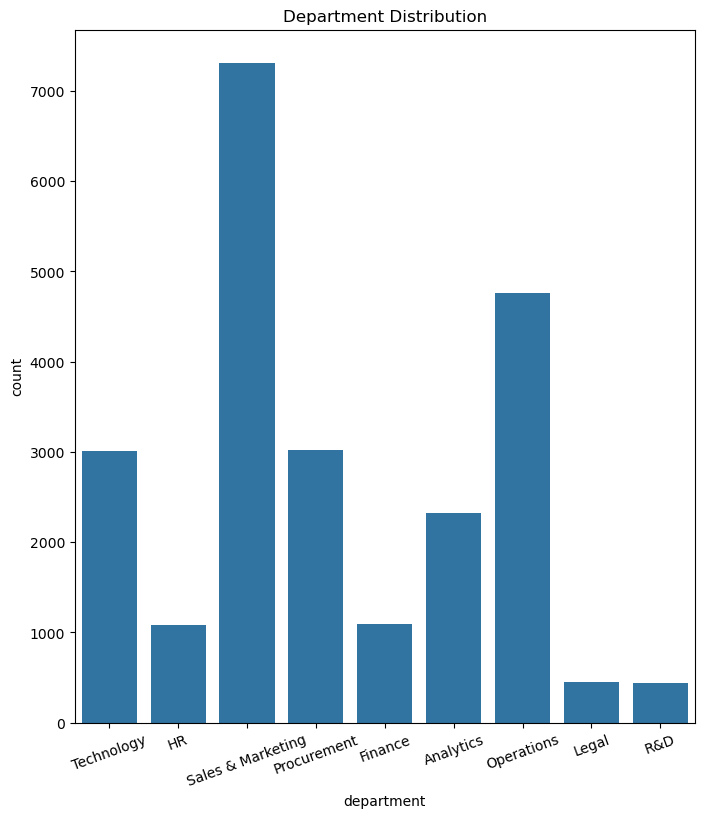

In [35]:
plt.figure(figsize=(8,9))
sns.countplot(x='department', data=df)
plt.title('Department Distribution')
plt.xticks(rotation=20)
plt.show()

### insights:
The employee count varies across different departments.
Some departments have significantly more employees than others.
This indicates an uneven workforce distribution across departments.

## Gender Distribution

C:\Users\trive\AppData\Local\Temp\ipykernel_5724\754138626.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Male', 'Female'])


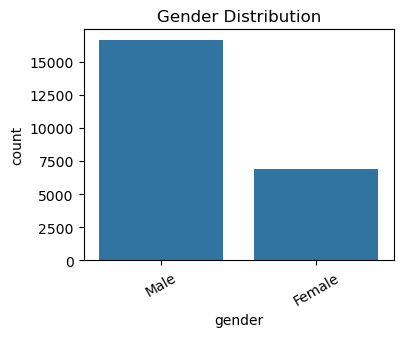

In [36]:
plt.figure(figsize=(4,3))
ax = sns.countplot(x='gender', data=df)
ax.set_xticklabels(['Male', 'Female'])
plt.title('Gender Distribution')
plt.xticks(rotation=30)
plt.show()

### insights
The dataset contains both male and female employees.
One gender has a higher representation than the other.

## Education Distribution

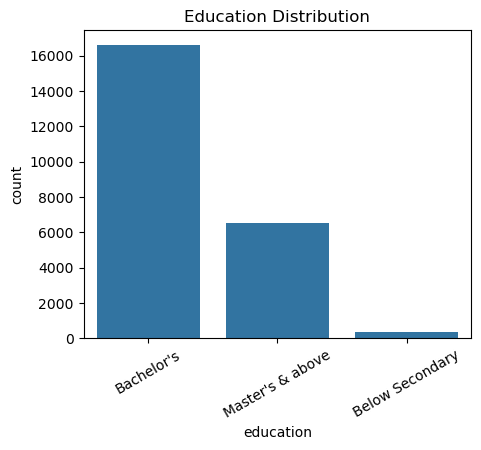

In [37]:
plt.figure(figsize=(5,4))
sns.countplot(x='education', data=df)
plt.title('Education Distribution')
plt.xticks(rotation=30)
plt.show()

#### insights:
Most employees belong to one education category (e.g., Bachelor's).
The other education categories have comparatively fewer employees.

## Recruitment Channel Distribution'

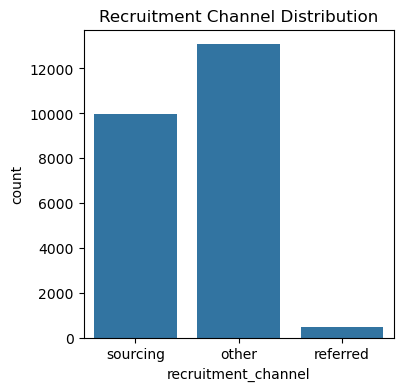

In [38]:
plt.figure(figsize=(4,4))
sns.countplot(x='recruitment_channel', data=df)
plt.title('Recruitment Channel Distribution')
plt.show()

#### insights:
Employees are recruited through multiple recruitment channels.
One recruitment channel contributes the majority of employees.

## KPI Achievement

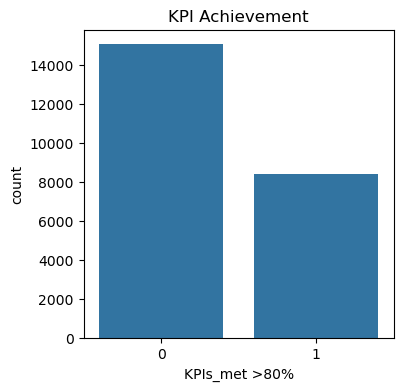

In [39]:
plt.figure(figsize=(4,4))
sns.countplot(x='KPIs_met >80%', data=df)
plt.title('KPI Achievement')
plt.show()

#### insights:
some employees met the KPI target of more than 80%, while others did not.

## Awards Won

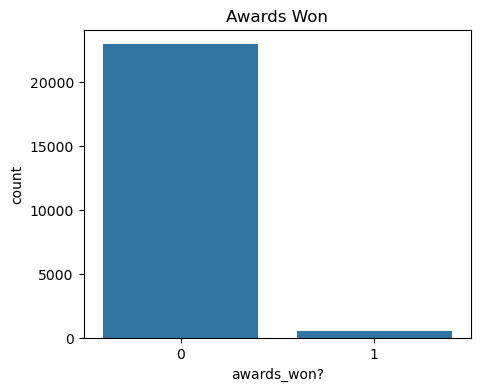

In [40]:
plt.figure(figsize=(5,4))
sns.countplot(x='awards_won?', data=df)
plt.title('Awards Won')
plt.show()

#### insights:

#### insights:
Most employees have not received awards.
Only a small proportion of employees have won awards.

# Data Scaling

In [41]:
# apply label encoding
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
categorical_cols=['department','region','education','gender','recruitment_channel']
for col in categorical_cols :
   df[col]=le.fit_transform(df[col])

In [42]:
df.dtypes

employee_id               int64
department                int64
region                    int64
education                 int64
gender                    int64
recruitment_channel       int64
no_of_trainings           int64
age                       int64
previous_year_rating    float64
length_of_service         int64
KPIs_met >80%             int64
awards_won?               int64
avg_training_score        int64
dtype: object

#### Separate Features (X) and Target (y)

In [43]:
X = df.drop(['employee_id', 'KPIs_met >80%'], axis=1)
y = df['KPIs_met >80%']

#### Split the Dataset into Training and Testing Sets ✅ Required

In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

#### Scale the data

In [45]:
#Import Required Libraries
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler, MaxAbsScaler

In [46]:
# Create the Scaling Function
def scale_data(X_train, X_test, numerical_cols, scaler):
    X_train_scaled = X_train.copy()
    X_test_scaled = X_test.copy()

    X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
    X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])

    return X_train_scaled, X_test_scaled


In [47]:
#Define Numerical Columns
numerical_cols = ['no_of_trainings','age','previous_year_rating','length_of_service','avg_training_score']

#### Apply Different Scalers

In [48]:
#StandardScaler

X_train_std, X_test_std = scale_data(
    X_train, X_test, numerical_cols, StandardScaler()
)

In [49]:
#RobustScaler

X_train_robust, X_test_robust = scale_data(
    X_train, X_test, numerical_cols, RobustScaler()
)

In [50]:
#MinMaxScaler

X_train_minmax, X_test_minmax = scale_data(
    X_train, X_test, numerical_cols, MinMaxScaler()
)

In [51]:
#MaxAbsScaler

X_train_maxabs, X_test_maxabs = scale_data(
    X_train, X_test, numerical_cols, MaxAbsScaler()
)

#### View the Scaled Data

In [52]:
X_train_std.head()

,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won?,avg_training_score
17620,0,14,0,1,0,-0.425366,-0.621580,-0.257489,-0.669338,0,1.918630
21335,6,11,2,1,2,-0.425366,1.463683,1.388337,2.422123,0,1.396931
9770,7,28,0,0,2,-0.425366,-0.621580,0.565424,-0.193729,0,-1.137034
21912,0,2,2,1,0,-0.425366,0.160394,0.565424,0.995295,0,1.471460
316,7,31,2,0,2,-0.425366,-0.360922,1.388337,0.281881,0,-0.764392


In [53]:
X_train_robust.head()

,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won?,avg_training_score
17620,0,14,0,1,0,0.0,-0.3,0.0,-0.50,0,1.16
21335,6,11,2,1,2,0.0,1.3,2.0,2.75,0,0.88
9770,7,28,0,0,2,0.0,-0.3,1.0,0.00,0,-0.48
21912,0,2,2,1,0,0.0,0.3,1.0,1.25,0,0.92
316,7,31,2,0,2,0.0,-0.1,2.0,0.50,0,-0.28


In [54]:
X_train_minmax.head()

,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won?,avg_training_score
17620,0,14,0,1,0,0.0,0.25,0.50,0.060606,0,0.833333
21335,6,11,2,1,2,0.0,0.65,1.00,0.454545,0,0.716667
9770,7,28,0,0,2,0.0,0.25,0.75,0.121212,0,0.150000
21912,0,2,2,1,0,0.0,0.40,0.75,0.272727,0,0.733333
316,7,31,2,0,2,0.0,0.30,1.00,0.181818,0,0.233333


In [55]:
X_train_maxabs.head()

,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won?,avg_training_score
17620,0,14,0,1,0,0.111111,0.500000,0.6,0.088235,0,0.898990
21335,6,11,2,1,2,0.111111,0.766667,1.0,0.470588,0,0.828283
9770,7,28,0,0,2,0.111111,0.500000,0.8,0.147059,0,0.484848
21912,0,2,2,1,0,0.111111,0.600000,0.8,0.294118,0,0.838384
316,7,31,2,0,2,0.111111,0.533333,1.0,0.205882,0,0.535354


# Create Baseline ML Model for Binary Classification Problem

In [56]:
# installing libraries
!pip install xgboost
!pip install catboost
!pip install lightgbm

In [58]:
#Import Required Libraries

from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

In [59]:
#import required metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,accuracy_score
)

#### XGBoost Model

The XGBoost classifier was trained on the scaled training dataset. Model performance was evaluated using various metrics.

In [60]:
#Train XGBoost Model

xgb_model = XGBClassifier(random_state=42)
xgb_model.fit(X_train_std, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [61]:
#Make Predictions
y_pred_xgb = xgb_model.predict(X_test)
train_pred_xgb = xgb_model.predict(X_train)

In [62]:
# Training and Testing Accuracy
train_accuracy_xgb = accuracy_score(y_train, train_pred_xgb)
test_accuracy_xgb = accuracy_score(y_test, y_pred_xgb)

print("========== XGBoost Evaluation ==========")
print("Training Accuracy :", train_accuracy_xgb)
print("Testing Accuracy  :", test_accuracy_xgb)
print("Precision         :", precision_score(y_test, y_pred_xgb, average='weighted'))
print("Recall            :", recall_score(y_test, y_pred_xgb, average='weighted'))
print("F1 Score          :", f1_score(y_test, y_pred_xgb, average='weighted'))

========== XGBoost Evaluation ==========
Training Accuracy : 0.5551830566198382
Testing Accuracy  : 0.5530012771392082
Precision         : 0.5301548654083188
Recall            : 0.5530012771392082
F1 Score          : 0.5381191482343173


In [63]:
#Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))


Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.71      0.67      2984
           1       0.35      0.27      0.31      1714

    accuracy                           0.55      4698
   macro avg       0.49      0.49      0.49      4698
weighted avg       0.53      0.55      0.54      4698



#### CatBoost

The CatBoost classifier was trained on the scaled training dataset. Model performance was evaluated using various metrics.

In [64]:
#Train CatBoost Model
cat_model = CatBoostClassifier(random_state=42, verbose=0)
cat_model.fit(X_train_std,y_train) 

CatBoostClassifier(random_state=42, verbose=0)

In [65]:
# Predictions
y_pred_cat = cat_model.predict(X_test)
train_pred_cat = cat_model.predict(X_train)


In [66]:
# Training and Testing Accuracy
train_accuracy_cat = accuracy_score(y_train, train_pred_cat)
test_accuracy_cat = accuracy_score(y_test, y_pred_cat)

print("========== CatBoost Evaluation ==========")
print("Training Accuracy :", train_accuracy_cat)
print("Testing Accuracy  :", test_accuracy_cat)
print("Precision         :", precision_score(y_test, y_pred_cat, average='weighted'))
print("Recall            :", recall_score(y_test, y_pred_cat, average='weighted'))
print("F1 Score          :", f1_score(y_test, y_pred_cat, average='weighted'))

========== CatBoost Evaluation ==========
Training Accuracy : 0.4154959557258408
Testing Accuracy  : 0.4163473818646232
Precision         : 0.5426443243396606
Recall            : 0.4163473818646232
F1 Score          : 0.36519212984634836


In [67]:
#Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_cat))


Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.18      0.28      2984
           1       0.37      0.82      0.51      1714

    accuracy                           0.42      4698
   macro avg       0.51      0.50      0.40      4698
weighted avg       0.54      0.42      0.37      4698



#### LightGBM

The LightGBM classifier was trained on the scaled training dataset. Model performance was evaluated using various metrics.

In [71]:
#Train CatBoost Model
lgbm_model = LGBMClassifier(random_state=42)
lgbm_model.fit(X_train_std, y_train)

[LightGBM] [Info] Number of positive: 6715, number of negative: 12077
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001622 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 204
[LightGBM] [Info] Number of data points in the train set: 18792, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.357333 -> initscore=-0.586959
[LightGBM] [Info] Start training from score -0.586959


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [72]:
#Make Predictions
y_pred_lgb = lgbm_model.predict(X_test_std)
train_pred_lgb = lgbm_model.predict(X_train_std)

In [73]:
# Training and Testing Accuracy
train_accuracy_lgb = accuracy_score(y_train, train_pred_lgb)
test_accuracy_lgb = accuracy_score(y_test, y_pred_lgb)

print("========== LightGBM Evaluation ==========")
print("Training Accuracy :", train_accuracy_lgb)
print("Testing Accuracy  :", test_accuracy_lgb)
print("Precision         :", precision_score(y_test, y_pred_lgb, average='weighted'))
print("Recall            :", recall_score(y_test, y_pred_lgb, average='weighted'))
print("F1 Score          :", f1_score(y_test, y_pred_lgb, average='weighted'))

========== LightGBM Evaluation ==========
Training Accuracy : 0.751649638143891
Testing Accuracy  : 0.7075351213282248
Precision         : 0.6981575913745631
Recall            : 0.7075351213282248
F1 Score          : 0.6907074203354472


In [74]:
#Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lgb))


Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.87      0.79      2984
           1       0.65      0.43      0.52      1714

    accuracy                           0.71      4698
   macro avg       0.69      0.65      0.65      4698
weighted avg       0.70      0.71      0.69      4698



In [75]:
#Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lgb))


Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.87      0.79      2984
           1       0.65      0.43      0.52      1714

    accuracy                           0.71      4698
   macro avg       0.69      0.65      0.65      4698
weighted avg       0.70      0.71      0.69      4698



## Model Comparison Table

In [76]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["XGBoost", "CatBoost", "LightGBM"],
    "Training Accuracy": [
        train_accuracy_xgb,
        train_accuracy_cat,
        train_accuracy_lgb
    ],
    "Testing Accuracy": [
        test_accuracy_xgb,
        test_accuracy_cat,
        test_accuracy_lgb
    ],
    "Precision": [
        precision_score(y_test, y_pred_xgb, average='weighted'),
        precision_score(y_test, y_pred_cat, average='weighted'),
        precision_score(y_test, y_pred_lgb, average='weighted')
    ],
    "Recall": [
        recall_score(y_test, y_pred_xgb, average='weighted'),
        recall_score(y_test, y_pred_cat, average='weighted'),
        recall_score(y_test, y_pred_lgb, average='weighted')
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_xgb, average='weighted'),
        f1_score(y_test, y_pred_cat, average='weighted'),
        f1_score(y_test, y_pred_lgb, average='weighted')
    ]
})

print(results)

      Model  Training Accuracy  Testing Accuracy  Precision    Recall  \
0   XGBoost           0.555183          0.553001   0.530155  0.553001   
1  CatBoost           0.415496          0.416347   0.542644  0.416347   
2  LightGBM           0.751650          0.707535   0.698158  0.707535   

   F1 Score  
0  0.538119  
1  0.365192  
2  0.690707  


## Overfitting / Underfitting Analysis

In [77]:
print("===== Overfitting / Underfitting Analysis =====")

print("\nXGBoost")
print("Training Accuracy :", train_accuracy_xgb)
print("Testing Accuracy  :", test_accuracy_xgb)
print("Difference        :", abs(train_accuracy_xgb - test_accuracy_xgb))

print("\nCatBoost")
print("Training Accuracy :", train_accuracy_cat)
print("Testing Accuracy  :", test_accuracy_cat)
print("Difference        :", abs(train_accuracy_cat - test_accuracy_cat))

print("\nLightGBM")
print("Training Accuracy :", train_accuracy_lgb)
print("Testing Accuracy  :", test_accuracy_lgb)
print("Difference        :", abs(train_accuracy_lgb - test_accuracy_lgb))

===== Overfitting / Underfitting Analysis =====

XGBoost
Training Accuracy : 0.5551830566198382
Testing Accuracy  : 0.5530012771392082
Difference        : 0.0021817794806300306

CatBoost
Training Accuracy : 0.4154959557258408
Testing Accuracy  : 0.4163473818646232
Difference        : 0.0008514261387824185

LightGBM
Training Accuracy : 0.751649638143891
Testing Accuracy  : 0.7075351213282248
Difference        : 0.04411451681566614


##### Conclusion

LightGBM achieved the highest accuracy (70.75%) among the three baseline models and is the best-performing baseline model for this dataset.

# Report Results

## StandardScaler

In [78]:
#Apply StandardScaler
X_train_std, X_test_std = scale_data(
    X_train,
    X_test,
    numerical_cols,
    StandardScaler()
)

In [79]:
# XGBoost with StandardScaler

xgb_model = XGBClassifier(random_state=42)

xgb_model.fit(X_train_std, y_train)

# Predictions
y_pred_xgb_std = xgb_model.predict(X_test_std)
train_pred_xgb_std = xgb_model.predict(X_train_std)

# Accuracy
train_accuracy_xgb_std = accuracy_score(y_train, train_pred_xgb_std)
test_accuracy_xgb_std = accuracy_score(y_test, y_pred_xgb_std)

print("========== XGBoost (StandardScaler) ==========")
print("Training Accuracy :", train_accuracy_xgb_std)
print("Testing Accuracy  :", test_accuracy_xgb_std)
print("Precision         :", precision_score(y_test, y_pred_xgb_std, average='weighted'))
print("Recall            :", recall_score(y_test, y_pred_xgb_std, average='weighted'))
print("F1 Score          :", f1_score(y_test, y_pred_xgb_std, average='weighted'))

print("\nClassification Report")
print(classification_report(y_test, y_pred_xgb_std))
print("XGBoost - StandardScaler Accuracy:",
      accuracy_score(y_test, y_pred_xgb_std))

========== XGBoost (StandardScaler) ==========
Training Accuracy : 0.7976798637718178
Testing Accuracy  : 0.6994465730097914
Precision         : 0.6886248489114568
Recall            : 0.6994465730097914
F1 Score          : 0.684776966535956

Classification Report
              precision    recall  f1-score   support

           0       0.72      0.85      0.78      2984
           1       0.63      0.44      0.52      1714

    accuracy                           0.70      4698
   macro avg       0.68      0.64      0.65      4698
weighted avg       0.69      0.70      0.68      4698

XGBoost - StandardScaler Accuracy: 0.6994465730097914


In [81]:
#CatBoost with StandardScaler

cat_model = CatBoostClassifier(random_state=42, verbose=0)

cat_model.fit(X_train_std, y_train)

# Predictions
y_pred_cat_std = cat_model.predict(X_test_std)
train_pred_cat_std = cat_model.predict(X_train_std)

# Accuracy
train_accuracy_cat_std = accuracy_score(y_train, train_pred_cat_std)
test_accuracy_cat_std = accuracy_score(y_test, y_pred_cat_std)

print("========== CatBoost (StandardScaler) ==========")
print("Training Accuracy :", train_accuracy_cat_std)
print("Testing Accuracy  :", test_accuracy_cat_std)
print("Precision         :", precision_score(y_test, y_pred_cat_std, average='weighted'))
print("Recall            :", recall_score(y_test, y_pred_cat_std, average='weighted'))
print("F1 Score          :", f1_score(y_test, y_pred_cat_std, average='weighted'))

print("\nClassification Report")
print(classification_report(y_test, y_pred_cat_std))
print("CatBoost - StandardScaler Accuracy:",
      accuracy_score(y_test, y_pred_cat_std))

========== CatBoost (StandardScaler) ==========
Training Accuracy : 0.7641549595572584
Testing Accuracy  : 0.7041294167730949
Precision         : 0.6940647009731854
Recall            : 0.7041294167730949
F1 Score          : 0.6878524226987711

Classification Report
              precision    recall  f1-score   support

           0       0.72      0.86      0.79      2984
           1       0.64      0.43      0.52      1714

    accuracy                           0.70      4698
   macro avg       0.68      0.65      0.65      4698
weighted avg       0.69      0.70      0.69      4698

CatBoost - StandardScaler Accuracy: 0.7041294167730949


In [82]:
#LightGBM with StandardScaler

lgbm_model = LGBMClassifier(random_state=42)

lgbm_model.fit(X_train_std, y_train)

# Predictions
y_pred_lgbm_std = lgbm_model.predict(X_test_std)
train_pred_lgbm_std = lgbm_model.predict(X_train_std)

# Accuracy
train_accuracy_lgbm_std = accuracy_score(y_train, train_pred_lgbm_std)
test_accuracy_lgbm_std = accuracy_score(y_test, y_pred_lgbm_std)

print("========== LightGBM (StandardScaler) ==========")
print("Training Accuracy :", train_accuracy_lgbm_std)
print("Testing Accuracy  :", test_accuracy_lgbm_std)
print("Precision         :", precision_score(y_test, y_pred_lgbm_std, average='weighted'))
print("Recall            :", recall_score(y_test, y_pred_lgbm_std, average='weighted'))
print("F1 Score          :", f1_score(y_test, y_pred_lgbm_std, average='weighted'))


print("\nClassification Report")
print(classification_report(y_test, y_pred_lgbm_std))
print("LightGBM - StandardScaler Accuracy:",
      accuracy_score(y_test, y_pred_lgbm_std))

[LightGBM] [Info] Number of positive: 6715, number of negative: 12077
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001586 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 204
[LightGBM] [Info] Number of data points in the train set: 18792, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.357333 -> initscore=-0.586959
[LightGBM] [Info] Start training from score -0.586959
========== LightGBM (StandardScaler) ==========
Training Accuracy : 0.751649638143891
Testing Accuracy  : 0.7075351213282248
Precision         : 0.6981575913745631
Recall            : 0.7075351213282248
F1 Score          : 0.6907074203354472

Classification Report
              precision    recall  f1-score   support

           0       0.73      0.87      0.79      2984
           1       0.65      0.43      0.52      1714

    accuracy   

In [83]:
#Accuracy Comparison (StandardScaler)
results_std1= pd.DataFrame({
    "Model": ["XGBoost", "CatBoost", "LightGBM"],
    "Training Accuracy": [
        train_accuracy_xgb_std,
        train_accuracy_cat_std,
        train_accuracy_lgbm_std
    ],
    "Testing Accuracy": [
        test_accuracy_xgb_std,
        test_accuracy_cat_std,
        test_accuracy_lgbm_std
    ],
    "Precision": [
        precision_score(y_test, y_pred_xgb_std, average='weighted'),
        precision_score(y_test, y_pred_cat_std, average='weighted'),
        precision_score(y_test, y_pred_lgbm_std, average='weighted')
    ],
    "Recall": [
        recall_score(y_test, y_pred_xgb_std, average='weighted'),
        recall_score(y_test, y_pred_cat_std, average='weighted'),
        recall_score(y_test, y_pred_lgbm_std, average='weighted')
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_xgb_std, average='weighted'),
        f1_score(y_test, y_pred_cat_std, average='weighted'),
        f1_score(y_test, y_pred_lgbm_std, average='weighted')
    ]
})

print(results_std1)

      Model  Training Accuracy  Testing Accuracy  Precision    Recall  \
0   XGBoost           0.797680          0.699447   0.688625  0.699447   
1  CatBoost           0.764155          0.704129   0.694065  0.704129   
2  LightGBM           0.751650          0.707535   0.698158  0.707535   

   F1 Score  
0  0.684777  
1  0.687852  
2  0.690707  


## RobustScaler

In [84]:
#Apply RobustScaler
X_train_robust, X_test_robust = scale_data(
    X_train,
    X_test,
    numerical_cols,
    RobustScaler()
)

In [85]:
#XGBoost with RobustScaler

# Predictions
y_pred_xgb_robust = xgb_model.predict(X_test_robust)
train_pred_xgb_robust = xgb_model.predict(X_train_robust)

# Accuracy
train_accuracy_xgb_robust = accuracy_score(y_train, train_pred_xgb_robust)
test_accuracy_xgb_robust = accuracy_score(y_test, y_pred_xgb_robust)

print("========== XGBoost (RobustScaler) ==========")
print("Training Accuracy :", train_accuracy_xgb_robust)
print("Testing Accuracy  :", test_accuracy_xgb_robust)
print("Precision         :", precision_score(y_test, y_pred_xgb_robust, average='weighted'))
print("Recall            :", recall_score(y_test, y_pred_xgb_robust, average='weighted'))
print("F1 Score          :", f1_score(y_test, y_pred_xgb_robust, average='weighted'))


print("\nClassification Report")
print(classification_report(y_test, y_pred_xgb_robust))

print("XGBoost - RobustScaler Accuracy:",
      accuracy_score(y_test, y_pred_xgb_robust))

========== XGBoost (RobustScaler) ==========
Training Accuracy : 0.7261600681140911
Testing Accuracy  : 0.6945508727117923
Precision         : 0.683585903535035
Recall            : 0.6945508727117923
F1 Score          : 0.6719397588307071

Classification Report
              precision    recall  f1-score   support

           0       0.71      0.88      0.78      2984
           1       0.64      0.38      0.48      1714

    accuracy                           0.69      4698
   macro avg       0.67      0.63      0.63      4698
weighted avg       0.68      0.69      0.67      4698

XGBoost - RobustScaler Accuracy: 0.6945508727117923


In [86]:
#CatBoost with RobustScaler

# Predictions
y_pred_cat_robust = cat_model.predict(X_test_robust)
train_pred_cat_robust = cat_model.predict(X_train_robust)

# Accuracy
train_accuracy_cat_robust = accuracy_score(y_train, train_pred_cat_robust)
test_accuracy_cat_robust = accuracy_score(y_test, y_pred_cat_robust)

print("========== CatBoost (RobustScaler) ==========")
print("Training Accuracy :", train_accuracy_cat_robust)
print("Testing Accuracy  :", test_accuracy_cat_robust)
print("Precision         :", precision_score(y_test, y_pred_cat_robust, average='weighted'))
print("Recall            :", recall_score(y_test, y_pred_cat_robust, average='weighted'))
print("F1 Score          :", f1_score(y_test, y_pred_cat_robust, average='weighted'))


print("\nClassification Report")
print(classification_report(y_test, y_pred_cat_robust))
print("CatBoost - RobustScaler Accuracy:",
      accuracy_score(y_test, y_pred_cat_robust))

========== CatBoost (RobustScaler) ==========
Training Accuracy : 0.7030119199659429
Testing Accuracy  : 0.6864623243933589
Precision         : 0.6756924011290033
Recall            : 0.6864623243933589
F1 Score          : 0.6764746266994802

Classification Report
              precision    recall  f1-score   support

           0       0.72      0.82      0.77      2984
           1       0.59      0.46      0.52      1714

    accuracy                           0.69      4698
   macro avg       0.66      0.64      0.64      4698
weighted avg       0.68      0.69      0.68      4698

CatBoost - RobustScaler Accuracy: 0.6864623243933589


In [87]:
#LightGBM with RobustScaler

# Predictions
y_pred_lgbm_robust = lgbm_model.predict(X_test_robust)
train_pred_lgbm_robust = lgbm_model.predict(X_train_robust)

# Accuracy
train_accuracy_lgbm_robust = accuracy_score(y_train, train_pred_lgbm_robust)
test_accuracy_lgbm_robust = accuracy_score(y_test, y_pred_lgbm_robust)

print("========== LightGBM (RobustScaler) ==========")
print("Training Accuracy :", train_accuracy_lgbm_robust)
print("Testing Accuracy  :", test_accuracy_lgbm_robust)
print("Precision         :", precision_score(y_test, y_pred_lgbm_robust, average='weighted'))
print("Recall            :", recall_score(y_test, y_pred_lgbm_robust, average='weighted'))
print("F1 Score          :", f1_score(y_test, y_pred_lgbm_robust, average='weighted'))

print("\nClassification Report")
print(classification_report(y_test, y_pred_lgbm_robust))
print("LightGBM - RobustScaler Accuracy:",
      accuracy_score(y_test, y_pred_lgbm_robust))

========== LightGBM (RobustScaler) ==========
Training Accuracy : 0.6977969348659003
Testing Accuracy  : 0.6862494678586633
Precision         : 0.6755897174943966
Recall            : 0.6862494678586633
F1 Score          : 0.676494865010003

Classification Report
              precision    recall  f1-score   support

           0       0.73      0.81      0.77      2984
           1       0.59      0.46      0.52      1714

    accuracy                           0.69      4698
   macro avg       0.66      0.64      0.64      4698
weighted avg       0.68      0.69      0.68      4698

LightGBM - RobustScaler Accuracy: 0.6862494678586633


In [88]:
#Accuracy Comparison (RobustScaler)
results_robust = pd.DataFrame({
    "Model": ["XGBoost", "CatBoost", "LightGBM"],
    "Training Accuracy": [
        train_accuracy_xgb_robust,
        train_accuracy_cat_robust,
        train_accuracy_lgbm_robust
    ],
    "Testing Accuracy": [
        test_accuracy_xgb_robust,
        test_accuracy_cat_robust,
        test_accuracy_lgbm_robust
    ],
    "Precision": [
        precision_score(y_test, y_pred_xgb_robust, average='weighted'),
        precision_score(y_test, y_pred_cat_robust, average='weighted'),
        precision_score(y_test, y_pred_lgbm_robust, average='weighted')
    ],
    "Recall": [
        recall_score(y_test, y_pred_xgb_robust, average='weighted'),
        recall_score(y_test, y_pred_cat_robust, average='weighted'),
        recall_score(y_test, y_pred_lgbm_robust, average='weighted')
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_xgb_robust, average='weighted'),
        f1_score(y_test, y_pred_cat_robust, average='weighted'),
        f1_score(y_test, y_pred_lgbm_robust, average='weighted')
    ]
})

print(results_robust)

      Model  Training Accuracy  Testing Accuracy  Precision    Recall  \
0   XGBoost           0.726160          0.694551   0.683586  0.694551   
1  CatBoost           0.703012          0.686462   0.675692  0.686462   
2  LightGBM           0.697797          0.686249   0.675590  0.686249   

   F1 Score  
0  0.671940  
1  0.676475  
2  0.676495  


## MinMaxScaler

In [89]:
#Apply MinMaxScaler
X_train_minmax, X_test_minmax = scale_data(
    X_train,
    X_test,
    numerical_cols,
    MinMaxScaler()
)

In [90]:
#XGBoost with MinMaxScaler
xgb_minmax = XGBClassifier(random_state=42)

xgb_minmax.fit(X_train_minmax, y_train)

# Predictions
y_pred_xgb_minmax = xgb_model.predict(X_test_minmax)
train_pred_xgb_minmax = xgb_model.predict(X_train_minmax)

# Accuracy
train_accuracy_xgb_minmax = accuracy_score(y_train, train_pred_xgb_minmax)
test_accuracy_xgb_minmax = accuracy_score(y_test, y_pred_xgb_minmax)

print("========== XGBoost (MinMaxScaler) ==========")
print("Training Accuracy :", train_accuracy_xgb_minmax)
print("Testing Accuracy  :", test_accuracy_xgb_minmax)
print("Precision         :", precision_score(y_test, y_pred_xgb_minmax, average='weighted'))
print("Recall            :", recall_score(y_test, y_pred_xgb_minmax, average='weighted'))
print("F1 Score          :", f1_score(y_test, y_pred_xgb_minmax, average='weighted'))

print("\nClassification Report")
print(classification_report(y_test, y_pred_xgb_minmax))
print("XGBoost - MinMaxScaler Accuracy:",
      accuracy_score(y_test, y_pred_xgb_minmax))

========== XGBoost (MinMaxScaler) ==========
Training Accuracy : 0.6724137931034483
Testing Accuracy  : 0.6566624095359728
Precision         : 0.6355792524036282
Recall            : 0.6566624095359728
F1 Score          : 0.6071273207609357

Classification Report
              precision    recall  f1-score   support

           0       0.67      0.90      0.77      2984
           1       0.58      0.23      0.32      1714

    accuracy                           0.66      4698
   macro avg       0.62      0.56      0.55      4698
weighted avg       0.64      0.66      0.61      4698

XGBoost - MinMaxScaler Accuracy: 0.6566624095359728


In [91]:
#CatBoost with MinMaxScaler
cat_minmax = CatBoostClassifier(random_state=42, verbose=0)

cat_minmax.fit(X_train_minmax, y_train)

# Predictions
y_pred_cat_minmax = cat_model.predict(X_test_minmax)
train_pred_cat_minmax = cat_model.predict(X_train_minmax)

# Accuracy
train_accuracy_cat_minmax = accuracy_score(y_train, train_pred_cat_minmax)
test_accuracy_cat_minmax = accuracy_score(y_test, y_pred_cat_minmax)

print("========== CatBoost (MinMaxScaler) ==========")
print("Training Accuracy :", train_accuracy_cat_minmax)
print("Testing Accuracy  :", test_accuracy_cat_minmax)
print("Precision         :", precision_score(y_test, y_pred_cat_minmax, average='weighted'))
print("Recall            :", recall_score(y_test, y_pred_cat_minmax, average='weighted'))
print("F1 Score          :", f1_score(y_test, y_pred_cat_minmax, average='weighted'))


print("\nClassification Report")
print(classification_report(y_test, y_pred_cat_minmax))
print("CatBoost - MinMaxScaler Accuracy:",
      accuracy_score(y_test, y_pred_cat_minmax))

========== CatBoost (MinMaxScaler) ==========
Training Accuracy : 0.6701787994891443
Testing Accuracy  : 0.6530438484461473
Precision         : 0.6364503094093414
Recall            : 0.6530438484461473
F1 Score          : 0.637537220094288

Classification Report
              precision    recall  f1-score   support

           0       0.70      0.81      0.75      2984
           1       0.53      0.38      0.45      1714

    accuracy                           0.65      4698
   macro avg       0.61      0.60      0.60      4698
weighted avg       0.64      0.65      0.64      4698

CatBoost - MinMaxScaler Accuracy: 0.6530438484461473


In [92]:
#LightGBM with MinMaxScaler
lgbm_minmax = LGBMClassifier(random_state=42)

lgbm_minmax.fit(X_train_minmax, y_train)
# Predictions
y_pred_lgbm_minmax = lgbm_model.predict(X_test_minmax)
train_pred_lgbm_minmax = lgbm_model.predict(X_train_minmax)

# Accuracy
train_accuracy_lgbm_minmax = accuracy_score(y_train, train_pred_lgbm_minmax)
test_accuracy_lgbm_minmax = accuracy_score(y_test, y_pred_lgbm_minmax)

print("========== LightGBM (MinMaxScaler) ==========")
print("Training Accuracy :", train_accuracy_lgbm_minmax)
print("Testing Accuracy  :", test_accuracy_lgbm_minmax)
print("Precision         :", precision_score(y_test, y_pred_lgbm_minmax, average='weighted'))
print("Recall            :", recall_score(y_test, y_pred_lgbm_minmax, average='weighted'))
print("F1 Score          :", f1_score(y_test, y_pred_lgbm_minmax, average='weighted'))

print("\nClassification Report")
print(classification_report(y_test, y_pred_lgbm_minmax))
print("LightGBM - MinMaxScaler Accuracy:",
      accuracy_score(y_test, y_pred_lgbm_minmax))

[LightGBM] [Info] Number of positive: 6715, number of negative: 12077
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001861 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 200
[LightGBM] [Info] Number of data points in the train set: 18792, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.357333 -> initscore=-0.586959
[LightGBM] [Info] Start training from score -0.586959
========== LightGBM (MinMaxScaler) ==========
Training Accuracy : 0.6223925074499788
Testing Accuracy  : 0.6066411238825032
Precision         : 0.5837864394659253
Recall            : 0.6066411238825032
F1 Score          : 0.5886618813028386

Classification Report
              precision    recall  f1-score   support

           0       0.66      0.77      0.71      2984
           1       0.45      0.32      0.37      1714

    accuracy    

In [93]:
results_minmax = pd.DataFrame({
    "Model": ["XGBoost", "CatBoost", "LightGBM"],
    "Training Accuracy": [
        train_accuracy_xgb_minmax,
        train_accuracy_cat_minmax,
        train_accuracy_lgbm_minmax
    ],
    "Testing Accuracy": [
        test_accuracy_xgb_minmax,
        test_accuracy_cat_minmax,
        test_accuracy_lgbm_minmax
    ],
    "Precision": [
        precision_score(y_test, y_pred_xgb_minmax, average='weighted'),
        precision_score(y_test, y_pred_cat_minmax, average='weighted'),
        precision_score(y_test, y_pred_lgbm_minmax, average='weighted')
    ],
    "Recall": [
        recall_score(y_test, y_pred_xgb_minmax, average='weighted'),
        recall_score(y_test, y_pred_cat_minmax, average='weighted'),
        recall_score(y_test, y_pred_lgbm_minmax, average='weighted')
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_xgb_minmax, average='weighted'),
        f1_score(y_test, y_pred_cat_minmax, average='weighted'),
        f1_score(y_test, y_pred_lgbm_minmax, average='weighted')
    ]
})

print(results_minmax)

      Model  Training Accuracy  Testing Accuracy  Precision    Recall  \
0   XGBoost           0.672414          0.656662   0.635579  0.656662   
1  CatBoost           0.670179          0.653044   0.636450  0.653044   
2  LightGBM           0.622393          0.606641   0.583786  0.606641   

   F1 Score  
0  0.607127  
1  0.637537  
2  0.588662  


## MaxAbsScaler

In [94]:
#Apply MaxAbsScaler
X_train_maxabs, X_test_maxabs = scale_data(
    X_train,
    X_test,
    numerical_cols,
    MaxAbsScaler()
)

In [95]:
#XGBoost with MaxAbsScaler
xgb_maxabs = XGBClassifier(random_state=42)

xgb_maxabs.fit(X_train_maxabs, y_train)

# Predictions
y_pred_xgb_maxabs = xgb_model.predict(X_test_maxabs)
train_pred_xgb_maxabs = xgb_model.predict(X_train_maxabs)

# Accuracy
train_accuracy_xgb_maxabs = accuracy_score(y_train, train_pred_xgb_maxabs)
test_accuracy_xgb_maxabs = accuracy_score(y_test, y_pred_xgb_maxabs)

print("========== XGBoost (MaxAbsScaler) ==========")
print("Training Accuracy :", train_accuracy_xgb_maxabs)
print("Testing Accuracy  :", test_accuracy_xgb_maxabs)
print("Precision         :", precision_score(y_test, y_pred_xgb_maxabs, average='weighted'))
print("Recall            :", recall_score(y_test, y_pred_xgb_maxabs, average='weighted'))
print("F1 Score          :", f1_score(y_test, y_pred_xgb_maxabs, average='weighted'))

print("\nClassification Report")
print(classification_report(y_test, y_pred_xgb_maxabs))
print("XGBoost - MaxAbsScaler Accuracy:",
      accuracy_score(y_test, y_pred_xgb_maxabs))

========== XGBoost (MaxAbsScaler) ==========
Training Accuracy : 0.6341528309919114
Testing Accuracy  : 0.6232439335887612
Precision         : 0.5863865553728791
Recall            : 0.6232439335887612
F1 Score          : 0.5802440213635576

Classification Report
              precision    recall  f1-score   support

           0       0.66      0.86      0.74      2984
           1       0.47      0.22      0.30      1714

    accuracy                           0.62      4698
   macro avg       0.56      0.54      0.52      4698
weighted avg       0.59      0.62      0.58      4698

XGBoost - MaxAbsScaler Accuracy: 0.6232439335887612


In [96]:
#CatBoost with MaxAbsScaler
cat_maxabs = CatBoostClassifier(random_state=42, verbose=0)
cat_maxabs.fit(X_train_maxabs, y_train)

# Predictions
y_pred_cat_maxabs = cat_model.predict(X_test_maxabs)
train_pred_cat_maxabs = cat_model.predict(X_train_maxabs)

# Accuracy
train_accuracy_cat_maxabs = accuracy_score(y_train, train_pred_cat_maxabs)
test_accuracy_cat_maxabs = accuracy_score(y_test, y_pred_cat_maxabs)

print("========== CatBoost (MaxAbsScaler) ==========")
print("Training Accuracy :", train_accuracy_cat_maxabs)
print("Testing Accuracy  :", test_accuracy_cat_maxabs)
print("Precision         :", precision_score(y_test, y_pred_cat_maxabs, average='weighted'))
print("Recall            :", recall_score(y_test, y_pred_cat_maxabs, average='weighted'))
print("F1 Score          :", f1_score(y_test, y_pred_cat_maxabs, average='weighted'))


print("\nClassification Report")
print(classification_report(y_test, y_pred_cat_maxabs))
print("CatBoost - MaxAbsScaler Accuracy:",
      accuracy_score(y_test, y_pred_cat_maxabs))


========== CatBoost (MaxAbsScaler) ==========
Training Accuracy : 0.6372392507449979
Testing Accuracy  : 0.6255853554704129
Precision         : 0.606529064165337
Recall            : 0.6255853554704129
F1 Score          : 0.6101048341857304

Classification Report
              precision    recall  f1-score   support

           0       0.68      0.78      0.73      2984
           1       0.48      0.35      0.41      1714

    accuracy                           0.63      4698
   macro avg       0.58      0.57      0.57      4698
weighted avg       0.61      0.63      0.61      4698

CatBoost - MaxAbsScaler Accuracy: 0.6255853554704129


In [97]:
#LightGBM with MaxAbsScaler
lgbm_maxabs = LGBMClassifier(random_state=42)
lgbm_maxabs.fit(X_train_maxabs, y_train)

# Predictions
y_pred_lgbm_maxabs = lgbm_model.predict(X_test_maxabs)
train_pred_lgbm_maxabs = lgbm_model.predict(X_train_maxabs)

# Accuracy
train_accuracy_lgbm_maxabs = accuracy_score(y_train, train_pred_lgbm_maxabs)
test_accuracy_lgbm_maxabs = accuracy_score(y_test, y_pred_lgbm_maxabs)

print("========== LightGBM (MaxAbsScaler) ==========")
print("Training Accuracy :", train_accuracy_lgbm_maxabs)
print("Testing Accuracy  :", test_accuracy_lgbm_maxabs)
print("Precision         :", precision_score(y_test, y_pred_lgbm_maxabs, average='weighted'))
print("Recall            :", recall_score(y_test, y_pred_lgbm_maxabs, average='weighted'))
print("F1 Score          :", f1_score(y_test, y_pred_lgbm_maxabs, average='weighted'))

print("\nClassification Report")
print(classification_report(y_test, y_pred_lgbm_maxabs))

print("LightGBM - MaxAbsScaler Accuracy:",
      accuracy_score(y_test, y_pred_lgbm_maxabs))

[LightGBM] [Info] Number of positive: 6715, number of negative: 12077
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001750 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 204
[LightGBM] [Info] Number of data points in the train set: 18792, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.357333 -> initscore=-0.586959
[LightGBM] [Info] Start training from score -0.586959
========== LightGBM (MaxAbsScaler) ==========
Training Accuracy : 0.6568752660706684
Testing Accuracy  : 0.6464452958705832
Precision         : 0.618750005672714
Recall            : 0.6464452958705832
F1 Score          : 0.5862419647996421

Classification Report
              precision    recall  f1-score   support

           0       0.66      0.91      0.77      2984
           1       0.55      0.18      0.27      1714

    accuracy     

In [99]:
#Comparison table(MaxAbsScaler)
results_maxabs = pd.DataFrame({
    "Model": ["XGBoost", "CatBoost", "LightGBM"],
    "Training Accuracy": [
        train_accuracy_xgb_maxabs,
        train_accuracy_cat_maxabs,
        train_accuracy_lgbm_maxabs
    ],
    "Testing Accuracy": [
        test_accuracy_xgb_maxabs,
        test_accuracy_cat_maxabs,
        test_accuracy_lgbm_maxabs
    ],
    "Precision": [
        precision_score(y_test, y_pred_xgb_maxabs, average='weighted'),
        precision_score(y_test, y_pred_cat_maxabs, average='weighted'),
        precision_score(y_test, y_pred_lgbm_maxabs, average='weighted')
    ],
    "Recall": [
        recall_score(y_test, y_pred_xgb_maxabs, average='weighted'),
        recall_score(y_test, y_pred_cat_maxabs, average='weighted'),
        recall_score(y_test, y_pred_lgbm_maxabs, average='weighted')
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_xgb_maxabs, average='weighted'),
        f1_score(y_test, y_pred_cat_maxabs, average='weighted'),
        f1_score(y_test, y_pred_lgbm_maxabs, average='weighted')
    ]
})

print(results_maxabs)

      Model  Training Accuracy  Testing Accuracy  Precision    Recall  \
0   XGBoost           0.634153          0.623244   0.586387  0.623244   
1  CatBoost           0.637239          0.625585   0.606529  0.625585   
2  LightGBM           0.656875          0.646445   0.618750  0.646445   

   F1 Score  
0  0.580244  
1  0.610105  
2  0.586242  


### Comparison of All Scalers

In [100]:
# Best model from each scaler
best_std = results_std1.loc[results_std1["Testing Accuracy"].idxmax()]
best_minmax = results_minmax.loc[results_minmax["Testing Accuracy"].idxmax()]
best_robust = results_robust.loc[results_robust["Testing Accuracy"].idxmax()]
best_maxabs = results_maxabs.loc[results_maxabs["Testing Accuracy"].idxmax()]

# Final Comparison of All 4 Scalers
final_scaler_comparison = pd.DataFrame({
    "Scaler": ["StandardScaler", "MinMaxScaler", "RobustScaler", "MaxAbsScaler"],
    "Best Model": [
        best_std["Model"],
        best_minmax["Model"],
        best_robust["Model"],
        best_maxabs["Model"]
    ],
    "Training Accuracy": [
        best_std["Training Accuracy"],
        best_minmax["Training Accuracy"],
        best_robust["Training Accuracy"],
        best_maxabs["Training Accuracy"]
    ],
    "Testing Accuracy": [
        best_std["Testing Accuracy"],
        best_minmax["Testing Accuracy"],
        best_robust["Testing Accuracy"],
        best_maxabs["Testing Accuracy"]
    ],
    "Precision": [
        best_std["Precision"],
        best_minmax["Precision"],
        best_robust["Precision"],
        best_maxabs["Precision"]
    ],
    "Recall": [
        best_std["Recall"],
        best_minmax["Recall"],
        best_robust["Recall"],
        best_maxabs["Recall"]
    ],
    "F1 Score": [
        best_std["F1 Score"],
        best_minmax["F1 Score"],
        best_robust["F1 Score"],
        best_maxabs["F1 Score"]
    ]
})

print("===== Comparison of All 4 Scalers =====")
print(final_scaler_comparison)

===== Comparison of All 4 Scalers =====
           Scaler Best Model  Training Accuracy  Testing Accuracy  Precision  \
0  StandardScaler   LightGBM           0.751650          0.707535   0.698158   
1    MinMaxScaler    XGBoost           0.672414          0.656662   0.635579   
2    RobustScaler    XGBoost           0.726160          0.694551   0.683586   
3    MaxAbsScaler   LightGBM           0.656875          0.646445   0.618750   

     Recall  F1 Score  
0  0.707535  0.690707  
1  0.656662  0.607127  
2  0.694551  0.671940  
3  0.646445  0.586242  


### Conclusion:

Based on the comparison of all four feature scaling techniques, LightGBM with StandardScaler achieved the best overall performance for the Employee Performance Prediction System. It obtained the highest Testing Accuracy of 70.75% (0.707535), along with a Precision of 69.82% (0.698158), Recall of 70.75% (0.707535), and F1 Score of 69.07% (0.690707).

In [101]:
# Comparison of Machine Learning Models
model_comparison = pd.DataFrame({
    'Model': ['XGBoost', 'CatBoost', 'LightGBM'],
    'Training Accuracy': [
        train_accuracy_xgb_std,
        train_accuracy_cat_std,
        train_accuracy_lgbm_std
    ],
    'Testing Accuracy': [
        test_accuracy_xgb_std,
        test_accuracy_cat_std,
        test_accuracy_lgbm_std
    ],
    'Precision': [
        precision_score(y_test, y_pred_xgb_std, average='weighted'),
        precision_score(y_test, y_pred_cat_std, average='weighted'),
        precision_score(y_test, y_pred_lgbm_std, average='weighted')
    ],
    'Recall': [
        recall_score(y_test, y_pred_xgb_std, average='weighted'),
        recall_score(y_test, y_pred_cat_std, average='weighted'),
        recall_score(y_test, y_pred_lgbm_std, average='weighted')
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_xgb_std, average='weighted'),
        f1_score(y_test, y_pred_cat_std, average='weighted'),
        f1_score(y_test, y_pred_lgbm_std, average='weighted')
    ]
})

model_comparison

,Model,Training Accuracy,Testing Accuracy,Precision,Recall,F1 Score
0,XGBoost,0.797680,0.699447,0.688625,0.699447,0.684777
1,CatBoost,0.764155,0.704129,0.694065,0.704129,0.687852
2,LightGBM,0.751650,0.707535,0.698158,0.707535,0.690707


## Accuracy Comparison Across Different Scaling Techniques

In [102]:
accuracy_table = pd.DataFrame({
    "Model": [
        "XGBoost","XGBoost","XGBoost","XGBoost",
        "CatBoost","CatBoost","CatBoost","CatBoost",
        "LightGBM","LightGBM","LightGBM","LightGBM"
    ],

    "Scaler": [
        "StandardScaler","MinMaxScaler","RobustScaler","MaxAbsScaler",
        "StandardScaler","MinMaxScaler","RobustScaler","MaxAbsScaler",
        "StandardScaler","MinMaxScaler","RobustScaler","MaxAbsScaler"
    ],

    "Accuracy": [
        accuracy_score(y_test,y_pred_xgb_std),
        accuracy_score(y_test,y_pred_xgb_minmax),
        accuracy_score(y_test,y_pred_xgb_robust),
        accuracy_score(y_test,y_pred_xgb_maxabs),

        accuracy_score(y_test,y_pred_cat_std),
        accuracy_score(y_test,y_pred_cat_minmax),
        accuracy_score(y_test,y_pred_cat_robust),
        accuracy_score(y_test,y_pred_cat_maxabs),

        accuracy_score(y_test,y_pred_lgbm_std),
        accuracy_score(y_test,y_pred_lgbm_minmax),
        accuracy_score(y_test,y_pred_lgbm_robust),
        accuracy_score(y_test,y_pred_lgbm_maxabs)
    ]
})

accuracy_table

,Model,Scaler,Accuracy
0,XGBoost,StandardScaler,0.699447
1,XGBoost,MinMaxScaler,0.656662
2,XGBoost,RobustScaler,0.694551
3,XGBoost,MaxAbsScaler,0.623244
4,CatBoost,StandardScaler,0.704129
5,CatBoost,MinMaxScaler,0.653044
6,CatBoost,RobustScaler,0.686462
7,CatBoost,MaxAbsScaler,0.625585
8,LightGBM,StandardScaler,0.707535
9,LightGBM,MinMaxScaler,0.606641


##### conclusion

LightGBM achieved the highest accuracy of 70.75%, followed by CatBoost with 70.41% and XGBoost with 69.94%. These results indicate that StandardScaler is the most suitable scaling technique for this dataset, and LightGBM demonstrated the best predictive performance compared to the other evaluated models.